In [1]:
from tqdm import tqdm
import jiwer
import os
import torch
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

In [7]:
txt_dir = "../data/converted/commonvoice-to-vctk/txt"
wav_dir = "../data/converted/commonvoice-to-vctk/wav16_silence_trimmed"

In [3]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "openai/whisper-large-v3"

model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
)
model.to(device)

processor = AutoProcessor.from_pretrained(model_id)

pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    torch_dtype=torch_dtype,
    device=device,
)


Device set to use cuda:0


In [26]:
class CustomDataset:
    def __init__(self, txt_dir, wav_dir):
        self.txt_dir = txt_dir
        self.wav_dir = wav_dir
        self.txts = []
        self.wav_files = []
        for speaker in tqdm(os.listdir(txt_dir)):
            if not os.path.isdir(os.path.join(txt_dir, speaker)):
                continue
            for filename in os.listdir(os.path.join(txt_dir, speaker)):
                filename = filename.split(".")[0]
                txt_file = os.path.join(txt_dir, speaker, filename + ".txt")
                wav_file = os.path.join(wav_dir, speaker, f"{filename}_mic1" + ".flac")
                if os.path.exists(txt_file) and os.path.exists(wav_file):
                    with open(txt_file, "r") as f:
                        txt = f.read()
                    self.txts.append(txt)
                    self.wav_files.append(wav_file)

    def __len__(self):
        return len(self.txts)

    def __getitem__(self, idx):
        return self.txts[idx], self.wav_files[idx]

In [27]:
dataset = CustomDataset(txt_dir, wav_dir)

100%|██████████| 135/135 [00:02<00:00, 46.17it/s]


In [29]:
print(dataset[0])

('ปลาไหลปลาหลดเป็นปลาตัวยาว', '../data/converted/commonvoice-to-vctk/wav16_silence_trimmed/cv080/cv080_093_mic1.flac')


In [30]:
preset_batch_size = 32
dataloader = torch.utils.data.DataLoader(dataset, batch_size=preset_batch_size, shuffle=False)

In [31]:
for batch in dataloader:
    print(batch)
    break

[('ปลาไหลปลาหลดเป็นปลาตัวยาว', 'และจะปรับปรุงการตั้งตำแหน่งในระบบราชการเลิกการันตีตำแหน่งให้กับนักเรียน', 'ไม่ใช่มาถามม็อบ', 'ดาวน์โหลดข้อมูลที่', 'ใครถึงแล้ว', 'ดูดวงไพ่ยิปซีสิบสองราศีประจำวันที่ ห้าร้อยสิบเอ็ดเมษายนสองพันห้าร้อยหกสิบสี่', 'โดยเฉพาะด้านเทคโนโลยีให้ได้ครบทุกโรงเรียน', 'จัดกิจกรรมที่ทำให้ถนนกลางเมืองกลับมาคึกคัก', 'ก็มีลักษณะเช่นนั้น', 'คุณควรไปกราบอเมริกาไม่ใช่ไปด่าเขา', 'ขอทบทวนชื่อผู้ลี้ภัยไทยที่สูญหายระหว่างลี้ภัยหลัง', 'แต่ในหลายประเทศมิได้กำหนดให้พืชกระท่อมเป็นยาเสพติดให้โทษ', 'ทวิสเตอร์ตัวจริง', 'นอกจากเขาจะไม่ชัดเจนแล้ว', 'และใช้ความกล้าหาญอย่างมีวิจารณญาณหรือเปล่า', 'นั่นหมายความว่าผู้ที่อยู่บนเกาะบิ๊ก', 'มีเดลิเวอรี่ด้วย', 'การเงินไม่นิ่ง', 'คนจัดเขาคิดมากเนอะ ถ่ายทอดสดแปลภาษาห้องหลัก', 'สายการบินราคาประหยัด', 'นี่มีคำไทยมะ', 'แต่ละยี่ห้อ', 'กล่าวถึงนางหมาขาว', 'จะได้หลีกเลี่ยง', 'ช่างภาพข้างหน้าเขาบอกนะ ผมไม่รู้หรอก', 'เรื่องนี้เป็นผลดีอย่างไร', 'ชลิตาเอื้อบำรุงจิตบอกว่าหนังทดลองก็เหมือนซอฟต์แวร์เบต้า', 'หรือสิ่งที่ไม่ค่อยปลอดโปร่งใจนัก', 'ดังนั้นการดำเนินนโย

In [32]:
import warnings
warnings.filterwarnings("ignore")


In [33]:
out_dir = './transcribed_cv.txt'
batch_counter = 0
txts = []
transcripts = []
filenames = []

for batch in tqdm(dataloader, desc="Transcribing"):
    batch_size = len(batch[1])  # Get the actual batch size
    try:
        transcribed = pipe(list(batch[1]), batch_size=batch_size, generate_kwargs={"language": "thai"})  # Assuming batch[1] contains audio data
        transcripts.extend(["".join(t['text'].split()) for t in transcribed])
    except Exception as e:
        print(f"Error in batch {batch_counter}: {e}")
        transcripts.extend([-1] * batch_size)  # Fallback for errors
    
    filenames.extend(batch[1])
    txts.extend(["".join(t.split()) for t in list(batch[0])])  # Assuming batch[0] contains reference texts

    # Write to file every 20 batches
    if batch_counter % 20 == 0 and batch_counter > 0:
        with open(out_dir, "a") as f:
            for filename, txt, transcript in zip(filenames, txts, transcripts):
                f.write(f"{filename}|{txt}|{transcript}\n")
        
        txts.clear()
        transcripts.clear()
        filenames.clear()

    batch_counter += 1

# Write any remaining data after the loop
if txts:
    with open(out_dir, "a") as f:
        for filename, txt, transcript in zip(filenames, txts, transcripts):
            f.write(f"{filename}|{txt}|{transcript}\n")


Transcribing: 100%|██████████| 2905/2905 [4:03:36<00:00,  5.03s/it]  


In [1]:
import pandas as pd

df = pd.read_csv('transcribed_cv.txt', sep='|', header=None)
df.columns = ['filename', 'txt', 'transcript']
df

,filename,txt,transcript
0,../data/converted/commonvoice-to-vctk/wav16_si...,ปลาไหลปลาหลดเป็นปลาตัวยาว,หน้าไหนป้านดูดป้านตัวยาว
1,../data/converted/commonvoice-to-vctk/wav16_si...,และจะปรับปรุงการตั้งตำแหน่งในระบบราชการเลิกการ...,และจะปรับคุมการตั้งตำแหน่งในระบบราชการด้วยการั...
2,../data/converted/commonvoice-to-vctk/wav16_si...,ไม่ใช่มาถามม็อบ,ไม่ใช่มาถามบอก
3,../data/converted/commonvoice-to-vctk/wav16_si...,ดาวน์โหลดข้อมูลที่,แล้วโหลดข้อมูลที่
4,../data/converted/commonvoice-to-vctk/wav16_si...,ใครถึงแล้ว,ให้ถึงแล้ว
...,...,...,...
92951,../data/converted/commonvoice-to-vctk/wav16_si...,ฉันเพียงแค่หมายความว่าฉันไม่เข้าใจอลิซกล่าว,ฉันเพียงแค่หมายความว่าฉันไม่เข้าใจอลิสกล่าว
92952,../data/converted/commonvoice-to-vctk/wav16_si...,ด้วยเสื้อคลุมสีเทาตัวเดิม,ด้วยเสื้อคลุมสีเทาตัวเดิม
92953,../data/converted/commonvoice-to-vctk/wav16_si...,เราไม่รู้อะไรเกี่ยวกับเขาเลย,เราไม่รู้อะไรเกี่ยวกับเขาเลย
92954,../data/converted/commonvoice-to-vctk/wav16_si...,เขามีความพออกพอใจ,เขามีความพออกประใจ


In [2]:
import jiwer
from tqdm import tqdm

cers = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    txt = row['txt']
    transcript = row['transcript']
    cer = jiwer.cer(txt, transcript)
    cers.append(cer)
    df.at[i, 'cer'] = cer

df

100%|██████████| 92956/92956 [00:08<00:00, 11025.00it/s]


,filename,txt,transcript,cer
0,../data/converted/commonvoice-to-vctk/wav16_si...,ปลาไหลปลาหลดเป็นปลาตัวยาว,หน้าไหนป้านดูดป้านตัวยาว,0.520000
1,../data/converted/commonvoice-to-vctk/wav16_si...,และจะปรับปรุงการตั้งตำแหน่งในระบบราชการเลิกการ...,และจะปรับคุมการตั้งตำแหน่งในระบบราชการด้วยการั...,0.126761
2,../data/converted/commonvoice-to-vctk/wav16_si...,ไม่ใช่มาถามม็อบ,ไม่ใช่มาถามบอก,0.200000
3,../data/converted/commonvoice-to-vctk/wav16_si...,ดาวน์โหลดข้อมูลที่,แล้วโหลดข้อมูลที่,0.277778
4,../data/converted/commonvoice-to-vctk/wav16_si...,ใครถึงแล้ว,ให้ถึงแล้ว,0.200000
...,...,...,...,...
92951,../data/converted/commonvoice-to-vctk/wav16_si...,ฉันเพียงแค่หมายความว่าฉันไม่เข้าใจอลิซกล่าว,ฉันเพียงแค่หมายความว่าฉันไม่เข้าใจอลิสกล่าว,0.023256
92952,../data/converted/commonvoice-to-vctk/wav16_si...,ด้วยเสื้อคลุมสีเทาตัวเดิม,ด้วยเสื้อคลุมสีเทาตัวเดิม,0.000000
92953,../data/converted/commonvoice-to-vctk/wav16_si...,เราไม่รู้อะไรเกี่ยวกับเขาเลย,เราไม่รู้อะไรเกี่ยวกับเขาเลย,0.000000
92954,../data/converted/commonvoice-to-vctk/wav16_si...,เขามีความพออกพอใจ,เขามีความพออกประใจ,0.176471


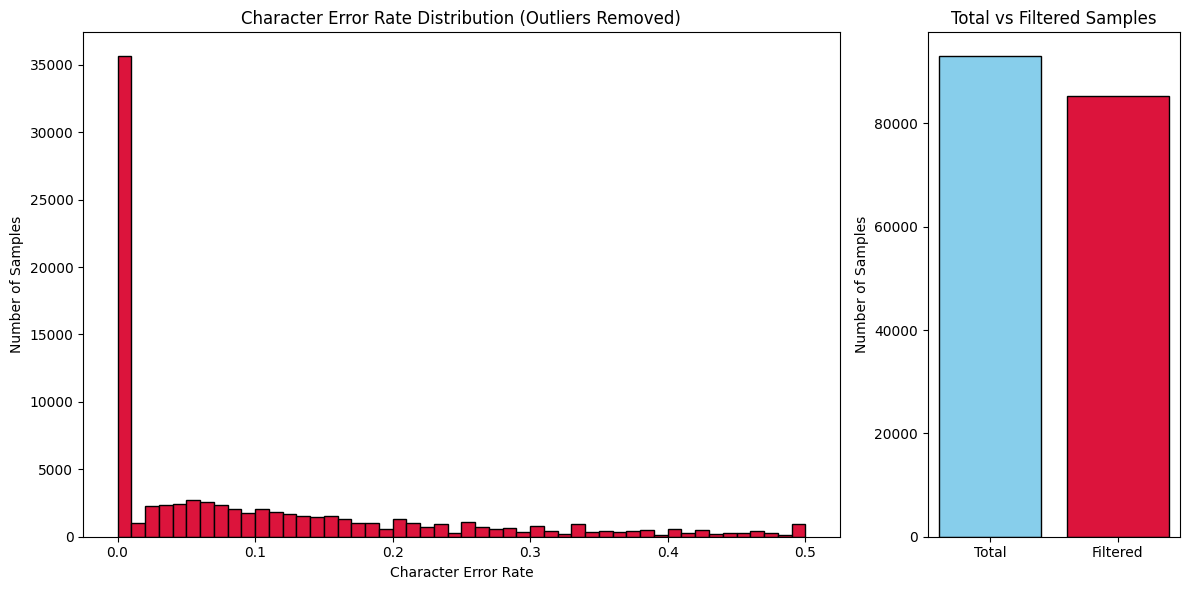

Outliers removed: 7688


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Compute Q1, Q3, and IQR
Q1 = np.percentile(cers, 25)
Q3 = np.percentile(cers, 75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
cers_filtered = [x for x in cers if lower_bound <= x <= upper_bound]

# Plot histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 1]})

# Left plot (75% width)
axes[0].hist(cers_filtered, bins=50, color='crimson', edgecolor='black')
axes[0].set_xlabel("Character Error Rate")
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("Character Error Rate Distribution (Outliers Removed)")

# Right plot (25% width)
axes[1].bar(["Total", "Filtered"], [len(cers), len(cers_filtered)], color=['skyblue', 'crimson'], edgecolor='black')
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Total vs Filtered Samples")

plt.tight_layout()
plt.show()

print(f"Outliers removed: {len(cers) - len(cers_filtered)}")

In [37]:
speaker_n_files = {}
speaker_perfect_transcripts = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    speaker = row['filename'].split('/')[-2]
    if speaker not in speaker_n_files:
        speaker_n_files[speaker] = 1
        speaker_perfect_transcripts[speaker] = 0
    else:
        speaker_n_files[speaker] += 1
    
    if round(row['cer'], 2) == 0:
        speaker_perfect_transcripts[speaker] += 1

print(speaker_n_files)
print(speaker_perfect_transcripts)


100%|██████████| 92956/92956 [00:03<00:00, 29904.76it/s]

{'cv080': 231, 'cv038': 125, 'cv109': 571, 'cv058': 163, 'cv036': 125, 'cv121': 954, 'cv016': 110, 'cv005': 101, 'cv034': 124, 'cv078': 218, 'cv087': 266, 'cv006': 104, 'cv094': 307, 'cv131': 3422, 'cv061': 165, 'cv056': 160, 'cv066': 177, 'cv106': 493, 'cv127': 2118, 'cv020': 112, 'cv097': 333, 'cv050': 148, 'cv046': 139, 'cv110': 575, 'cv033': 124, 'cv003': 100, 'cv096': 330, 'cv084': 247, 'cv072': 201, 'cv047': 140, 'cv011': 107, 'cv119': 907, 'cv010': 107, 'cv024': 117, 'cv053': 155, 'cv068': 192, 'cv055': 159, 'cv013': 109, 'cv077': 212, 'cv095': 312, 'cv075': 208, 'cv037': 125, 'cv117': 791, 'cv074': 203, 'cv014': 110, 'cv125': 1862, 'cv023': 116, 'cv041': 130, 'cv069': 195, 'cv031': 121, 'cv123': 1106, 'cv017': 111, 'cv044': 138, 'cv030': 120, 'cv067': 187, 'cv085': 248, 'cv048': 141, 'cv083': 243, 'cv059': 164, 'cv134': 26698, 'cv007': 104, 'cv129': 2208, 'cv027': 118, 'cv062': 167, 'cv045': 139, 'cv019': 112, 'cv025': 117, 'cv035': 124, 'cv004': 101, 'cv103': 441, 'cv028': 118

In [38]:
speaker_perfect_transcripts = dict(sorted(speaker_perfect_transcripts.items(), key=lambda x: x[1], reverse=True))
print(speaker_perfect_transcripts)

{'cv134': 9089, 'cv133': 4617, 'cv131': 1422, 'cv130': 1270, 'cv128': 925, 'cv132': 887, 'cv125': 795, 'cv127': 675, 'cv126': 585, 'cv122': 549, 'cv124': 547, 'cv123': 443, 'cv116': 422, 'cv117': 402, 'cv118': 398, 'cv129': 388, 'cv115': 378, 'cv120': 377, 'cv113': 356, 'cv121': 354, 'cv114': 292, 'cv107': 256, 'cv108': 256, 'cv111': 251, 'cv109': 248, 'cv102': 232, 'cv100': 228, 'cv112': 228, 'cv105': 218, 'cv099': 217, 'cv098': 213, 'cv104': 208, 'cv101': 193, 'cv106': 190, 'cv097': 186, 'cv096': 173, 'cv092': 168, 'cv103': 164, 'cv087': 159, 'cv110': 150, 'cv095': 137, 'cv070': 137, 'cv088': 129, 'cv068': 120, 'cv094': 118, 'cv079': 118, 'cv084': 117, 'cv075': 117, 'cv064': 116, 'cv081': 116, 'cv090': 114, 'cv067': 110, 'cv085': 110, 'cv089': 108, 'cv086': 105, 'cv053': 102, 'cv066': 98, 'cv062': 98, 'cv076': 97, 'cv093': 97, 'cv043': 94, 'cv073': 93, 'cv072': 91, 'cv059': 91, 'cv082': 85, 'cv074': 82, 'cv052': 81, 'cv056': 79, 'cv048': 78, 'cv083': 77, 'cv060': 77, 'cv058': 74, 'cv

In [39]:
for speaker in speaker_perfect_transcripts:
    if speaker_perfect_transcripts[speaker] >= 100:
        print(f"Speaker {speaker} has {speaker_perfect_transcripts[speaker]} perfect transcripts out of {speaker_n_files[speaker]} files")

Speaker cv134 has 9089 perfect transcripts out of 26698 files
Speaker cv133 has 4617 perfect transcripts out of 9669 files
Speaker cv131 has 1422 perfect transcripts out of 3422 files
Speaker cv130 has 1270 perfect transcripts out of 2741 files
Speaker cv128 has 925 perfect transcripts out of 2160 files
Speaker cv132 has 887 perfect transcripts out of 6081 files
Speaker cv125 has 795 perfect transcripts out of 1862 files
Speaker cv127 has 675 perfect transcripts out of 2118 files
Speaker cv126 has 585 perfect transcripts out of 2061 files
Speaker cv122 has 549 perfect transcripts out of 1023 files
Speaker cv124 has 547 perfect transcripts out of 1210 files
Speaker cv123 has 443 perfect transcripts out of 1106 files
Speaker cv116 has 422 perfect transcripts out of 781 files
Speaker cv117 has 402 perfect transcripts out of 791 files
Speaker cv118 has 398 perfect transcripts out of 855 files
Speaker cv129 has 388 perfect transcripts out of 2208 files
Speaker cv115 has 378 perfect transcri

In [40]:
ratios = {}
for speaker in speaker_perfect_transcripts:
    ratios[speaker] = speaker_perfect_transcripts[speaker] / speaker_n_files[speaker]

# sort by value
ratios = dict(sorted(ratios.items(), key=lambda item: item[1], reverse=True))
print(ratios)

{'cv043': 0.6962962962962963, 'cv070': 0.6954314720812182, 'cv064': 0.6705202312138728, 'cv053': 0.6580645161290323, 'cv098': 0.6320474777448071, 'cv068': 0.625, 'cv007': 0.625, 'cv014': 0.6, 'cv087': 0.5977443609022557, 'cv006': 0.5961538461538461, 'cv030': 0.5916666666666667, 'cv019': 0.5892857142857143, 'cv018': 0.5892857142857143, 'cv067': 0.5882352941176471, 'cv062': 0.5868263473053892, 'cv092': 0.5773195876288659, 'cv099': 0.5755968169761273, 'cv075': 0.5625, 'cv097': 0.5585585585585585, 'cv115': 0.5575221238938053, 'cv059': 0.5548780487804879, 'cv066': 0.5536723163841808, 'cv048': 0.5531914893617021, 'cv113': 0.5502318392581144, 'cv033': 0.5483870967741935, 'cv100': 0.5480769230769231, 'cv011': 0.5420560747663551, 'cv010': 0.5420560747663551, 'cv116': 0.5403329065300896, 'cv026': 0.5384615384615384, 'cv122': 0.5366568914956011, 'cv102': 0.5333333333333333, 'cv052': 0.5328947368421053, 'cv024': 0.5299145299145299, 'cv015': 0.5272727272727272, 'cv096': 0.5242424242424243, 'cv028':

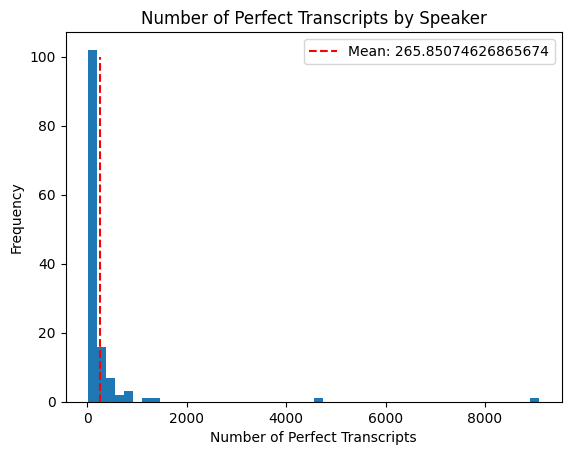

In [41]:
# plt hist by speaker
mean_perfect_transcripts = np.mean(list(speaker_perfect_transcripts.values()))
plt.hist(speaker_perfect_transcripts.values(), bins=50)
plt.vlines(mean_perfect_transcripts, 0, 100, colors='r', linestyles='dashed', label=f'Mean: {mean_perfect_transcripts}')
plt.legend()
plt.xlabel("Number of Perfect Transcripts")
plt.ylabel("Frequency")
plt.title("Number of Perfect Transcripts by Speaker")
plt.show()

In [42]:
qualified_speakers = []
for speaker in speaker_perfect_transcripts:
    n_perfect = speaker_perfect_transcripts[speaker]
    if n_perfect >= 20:
        qualified_speakers.append(speaker)

print(qualified_speakers)
print(len(qualified_speakers))

['cv134', 'cv133', 'cv131', 'cv130', 'cv128', 'cv132', 'cv125', 'cv127', 'cv126', 'cv122', 'cv124', 'cv123', 'cv116', 'cv117', 'cv118', 'cv129', 'cv115', 'cv120', 'cv113', 'cv121', 'cv114', 'cv107', 'cv108', 'cv111', 'cv109', 'cv102', 'cv100', 'cv112', 'cv105', 'cv099', 'cv098', 'cv104', 'cv101', 'cv106', 'cv097', 'cv096', 'cv092', 'cv103', 'cv087', 'cv110', 'cv095', 'cv070', 'cv088', 'cv068', 'cv094', 'cv079', 'cv084', 'cv075', 'cv064', 'cv081', 'cv090', 'cv067', 'cv085', 'cv089', 'cv086', 'cv053', 'cv066', 'cv062', 'cv076', 'cv093', 'cv043', 'cv073', 'cv072', 'cv059', 'cv082', 'cv074', 'cv052', 'cv056', 'cv048', 'cv083', 'cv060', 'cv058', 'cv050', 'cv030', 'cv091', 'cv047', 'cv057', 'cv033', 'cv077', 'cv065', 'cv061', 'cv014', 'cv019', 'cv018', 'cv007', 'cv026', 'cv006', 'cv024', 'cv054', 'cv034', 'cv035', 'cv028', 'cv046', 'cv036', 'cv031', 'cv044', 'cv042', 'cv011', 'cv010', 'cv015', 'cv025', 'cv078', 'cv009', 'cv063', 'cv051', 'cv005', 'cv049', 'cv003', 'cv119', 'cv041', 'cv021', 

In [43]:
qualified_files = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    speaker = row['filename'].split('/')[-2]
    if speaker in qualified_speakers and round(row['cer'], 2) == 0:
        qualified_files.append(row['filename'])

# save to file
with open('qualified_files_cv.txt', 'w') as f:
    for file in qualified_files:
        f.write(f"{file}\n")


100%|██████████| 92956/92956 [00:03<00:00, 30558.30it/s]


In [44]:
print(len(qualified_files))

35624
